In [1]:
import pandas as pd
import warnings
import numpy as np
warnings.filterwarnings("ignore")

## Estrazione dati da MongoDB

In [2]:
from pymongo import MongoClient
from dotenv import load_dotenv
import os

In [3]:
load_dotenv()
MONGO_URI = os.getenv("MONGO_URI")

client = MongoClient(MONGO_URI)
db=client["PolymerPrediction"]
collection=db["bicerano_tg"]

#print(collection.count_documents({}))

In [4]:
docs = list(collection.find({}))
df = pd.DataFrame(docs)

# espando il dizionario "properties"
prop_df = pd.json_normalize(df["properties"])

# integro nel dataframe
df = pd.concat([df.drop(columns=["properties"]), prop_df], axis=1)

# rimuovo righe senza SMILES o Tg
df = df.dropna(subset=["smiles", "Tg"])

df.head()


,_id,polymer_name,smiles,bigsmiles,source_dataset,Tg,density
0,694548f13273b7f305d9878b,"Poly(2-n-butyl-1,4-butadiene)",*CC=C(C*)CCCC,{$CC=C(CCCC)C$},BiceranoTg,192,None
1,694548f13273b7f305d987ca,Poly[(4-dimethylaminophenyl) methylsilylenetri...,*CCC[Si](*)(C)c1ccc(N(C)C)cc1,{<CCC[Si](c1ccc(N(C)C)cc1)(C)>},BiceranoTg,267,None
2,694548f13273b7f305d987d0,Poly(oxydiphenylsilylene oxydimethylsilylene-1...,*O[Si](O[Si](C)(C)c1ccc([Si](*)(C)C)cc1)(c1ccc...,{<O[Si](c1ccccc1)(c1ccccc1)O[Si](C)(C)c1ccc(cc...,BiceranoTg,273,None
3,694548f13273b7f305d9882c,Poly(m-methyl styrene),*CC(*)c1cccc(C)c1,{$CC(c1cccc(C)c1)$},BiceranoTg,370,None
4,694548f13273b7f305d98835,Poly(o-vinyl pyridine),*CC(*)c1ccccn1,{$CC(c1ccccn1)$},BiceranoTg,377,None


## Integrazione descrittori RDKit

In [5]:
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
import numpy as np

descriptor_names = [desc[0] for desc in Descriptors._descList]
calc = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)
# print(descriptor_names)

def rdkit_descr(smi):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return {d: np.nan for d in descriptor_names}
    values = calc.CalcDescriptors(mol)
    return dict(zip(descriptor_names, values))

desc_df = df["smiles"].apply(rdkit_descr).apply(pd.Series)
desc_df.head()

,MaxEStateIndex,MinEStateIndex,MaxAbsEStateIndex,MinAbsEStateIndex,qed,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,2.544306,0.632879,2.544306,0.632879,0.477046,110.200,96.088,110.109550,46.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.618380,-0.886614,2.618380,0.509221,0.667453,205.377,186.225,205.128676,76.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,7.203425,-2.696258,7.203425,0.298182,0.561875,406.706,380.498,406.124060,138.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2.374491,0.539815,2.374491,0.539815,0.559483,118.179,108.099,118.078250,46.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4.351991,0.491759,4.351991,0.491759,0.556779,105.140,98.084,105.057849,40.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


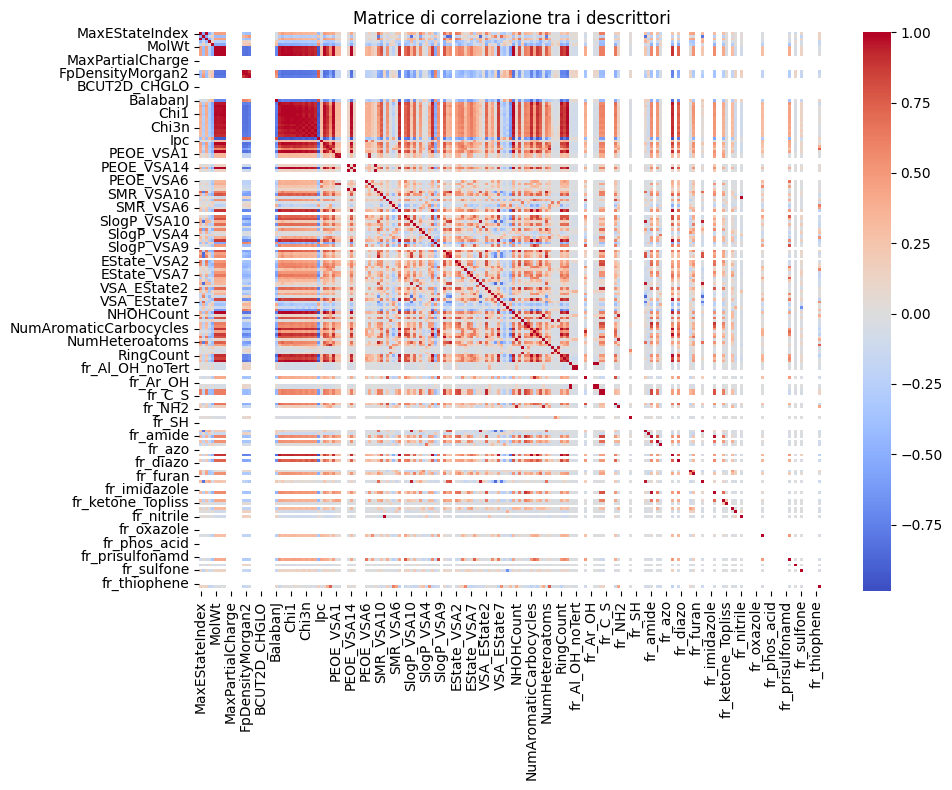

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt


corr = desc_df.corr(method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matrice di correlazione tra i descrittori")
plt.tight_layout()
plt.show()

## Aggiunta Fingerprint

In [7]:
from rdkit.Chem import rdFingerprintGenerator

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

def morgan_fp(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return [0]*1024
    fp = morgan_gen.GetFingerprint(mol)  
    return list(fp)

fp_df = df["smiles"].apply(morgan_fp).apply(pd.Series)
fp_df.columns = [f"fp_{i}" for i in range(fp_df.shape[1])]

In [8]:
from rdkit.Chem import MACCSkeys

def maccs_fp(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return [0]*167  # MACCS ha 167 bit (indice 0 inutilizzato)
    fp = MACCSkeys.GenMACCSKeys(mol)
    return list(fp)
maccs_df = df["smiles"].apply(maccs_fp).apply(pd.Series)
maccs_df.columns=[f"maccs_{i}" for i in range(167)]

feature_df = pd.concat([desc_df, fp_df, maccs_df], axis=1)

## Mordred

In [9]:
from mordred import Calculator, descriptors

# calcolatore Mordred (2D, niente 3D)
calc = Calculator(descriptors, ignore_3D=True)

mols = [Chem.MolFromSmiles(s) for s in df["smiles"]]
# calcolo descrittori
mordred_df = calc.pandas(mols)

print(mordred_df.shape)

# rimuove colonne tutte NaN
mordred_df = mordred_df.dropna(axis=1, how="all")

# converte tutto a numerico (NaN dove non convertibile)
mordred_df = mordred_df.apply(pd.to_numeric, errors="coerce")


 10%|████████▎                                                                        | 31/304 [00:23<00:58,  4.67it/s]

C:\Users\Vale\OneDrive\Desktop\uni\tirocinio\tgEnv310\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Vale\OneDrive\Desktop\uni\tirocinio\tgEnv310\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 27%|█████████████████████▌                                                           | 81/304 [00:27<00:24,  9.21it/s]

C:\Users\Vale\OneDrive\Desktop\uni\tirocinio\tgEnv310\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 29%|███████████████████████▍                                                         | 88/304 [00:28<00:26,  8.17it/s]

...

C:\Users\Vale\OneDrive\Desktop\uni\tirocinio\tgEnv310\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 85%|███████████████████████████████████████████████████████████████████▉            | 258/304 [00:41<00:04, 10.79it/s]

C:\Users\Vale\OneDrive\Desktop\uni\tirocinio\tgEnv310\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


100%|████████████████████████████████████████████████████████████████████████████████| 304/304 [00:42<00:00,  7.08it/s]


(304, 1613)


In [10]:
X_base = feature_df.copy()       
X_mordred = mordred_df.copy()
X_mordred.index = feature_df.index
feature_df = pd.concat([X_base, X_mordred], axis=1)

## Pulizia dei dati

In [11]:
feature_df = feature_df.replace([np.inf, -np.inf], np.nan)
feature_df = feature_df.fillna(feature_df.median(numeric_only=True))
feature_df = feature_df.dropna(axis=1, how="all")

# rimuovo colonne costanti (con varianza 0) 
from sklearn.feature_selection import VarianceThreshold

sel = VarianceThreshold(threshold=0.0)
sel.fit(feature_df)

mask = sel.get_support()
feature_df = feature_df.loc[:, mask]

print("Shape:", feature_df.shape[1])

Shape: 1577


In [12]:
print( feature_df.shape)
dup = feature_df.columns.to_numpy()[feature_df.columns.duplicated()]
print( dup)
feature_df.drop(columns=dup,inplace=True)
res1 =  np.unique(feature_df.columns,return_counts=True)
print(res1)

(304, 1577)
['BalabanJ' 'BertzCT' 'LabuteASA' 'PEOE_VSA1' 'PEOE_VSA2' 'PEOE_VSA6'
 'PEOE_VSA7' 'PEOE_VSA8' 'PEOE_VSA9' 'PEOE_VSA10' 'PEOE_VSA13' 'SMR_VSA1'
 'SMR_VSA2' 'SMR_VSA3' 'SMR_VSA4' 'SMR_VSA5' 'SMR_VSA6' 'SMR_VSA7'
 'SMR_VSA9' 'SlogP_VSA1' 'SlogP_VSA2' 'SlogP_VSA3' 'SlogP_VSA4'
 'SlogP_VSA5' 'SlogP_VSA6' 'SlogP_VSA7' 'SlogP_VSA8' 'SlogP_VSA10'
 'SlogP_VSA11' 'EState_VSA1' 'EState_VSA2' 'EState_VSA3' 'EState_VSA4'
 'EState_VSA5' 'EState_VSA6' 'EState_VSA7' 'EState_VSA8' 'EState_VSA9'
 'EState_VSA10' 'VSA_EState1' 'VSA_EState2' 'VSA_EState3' 'VSA_EState4'
 'VSA_EState5' 'VSA_EState6' 'VSA_EState7' 'VSA_EState8' 'VSA_EState9']
(array(['AATS0Z', 'AATS0d', 'AATS0dv', ..., 'piPC8', 'piPC9', 'qed'],
      dtype=object), array([1, 1, 1, ..., 1, 1, 1], dtype=int64))


## Preparazione dataset (separazione target)

In [13]:
y = df["Tg"]
X = feature_df.copy()
X.index = df["_id"]
print("Shape X:", X.shape)
print("Shape y:", y.shape)
X.sample(10)

import numpy as np

X_np = np.ascontiguousarray(X.to_numpy(), dtype=np.float32)

print("dtype:", X_np.dtype)
print("contiguous:", X_np.flags['C_CONTIGUOUS'])
print("finite:", np.isfinite(X_np).all())
print("max abs:", np.max(np.abs(X_np)))


Shape X: (304, 1481)
Shape y: (304,)
dtype: float32
contiguous: True
finite: True
max abs: 92832150000000.0


## Feature selection

### Mutual Info Regression

In [15]:
from sklearn.feature_selection import mutual_info_regression

random_state=25

mi_scores = mutual_info_regression(X, y, random_state=random_state)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# selezioniamo le top N feature
N = 300
top_features_mi = mi_series.head(N).index

X_mi_selected = X[top_features_mi]
print(X_mi_selected.shape)
print(X.shape)
print("Feature scelte (MI):", len(top_features_mi))

(304, 300)
(304, 1481)
Feature scelte (MI): 300


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X_mi_selected, y, test_size=0.2, random_state=random_state
)

model_mi = GradientBoostingRegressor(random_state=random_state)
model_mi.fit(X_train, y_train)

pred_mi = model_mi.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred_mi))
print("R²:", r2_score(y_test, pred_mi))


MAE: 27.807780345795614
R²: 0.911723665388603


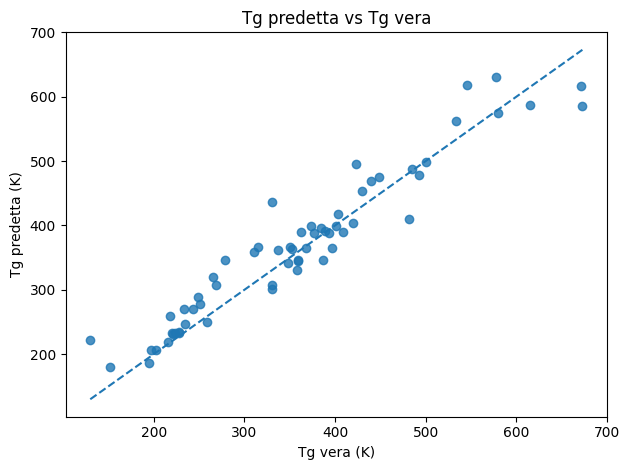

In [17]:
from matplotlib import pyplot as plt
plt.figure()
plt.scatter(y_test, pred_mi, alpha=0.8)


# diagonale ideale
min_val = min(y_test.min(), pred_mi.min())
max_val = max(y_test.max(), pred_mi.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Tg vera (K)")
plt.ylabel("Tg predetta (K)")
plt.title("Tg predetta vs Tg vera")

plt.tight_layout()
plt.show()

### Permutation importance
Uso il modello del passaggio precedente perché serve un modello già addestrato e abbastanza buono

In [18]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

perm = permutation_importance(model_mi, X_mi_selected, y, n_repeats=10, random_state=random_state)
perm_series = pd.Series(perm.importances_mean, index=X_mi_selected.columns)


In [19]:
print( np.unique(X_mi_selected.columns,    return_counts=True))

(array(['AATS0Z', 'AATS0d', 'AATS0dv', 'AATS1Z', 'AATS1d', 'AATS1dv',
       'AATS2Z', 'AATS2d', 'AATS2dv', 'AATS3Z', 'AATS3d', 'AATS3dv',
       'AATS4Z', 'AATS4d', 'AATS4dv', 'AATS5d', 'AATS5dv', 'AATS6Z',
       'AATS6d', 'AATS6dv', 'AATS7Z', 'AATS7d', 'AATS7dv', 'AATS8Z',
       'AATS8d', 'AATS8dv', 'AATSC0d', 'AATSC1Z', 'AATSC2Z', 'AETA_beta',
       'AETA_beta_ns', 'AETA_beta_ns_d', 'AETA_beta_s', 'AETA_dBeta',
       'AETA_eta_B', 'AETA_eta_BR', 'AETA_eta_R', 'AETA_eta_RL', 'AMID',
       'AMW', 'ATS0Z', 'ATS0d', 'ATS0dv', 'ATS1Z', 'ATS1d', 'ATS1dv',
       'ATS2Z', 'ATS2d', 'ATS2dv', 'ATS3Z', 'ATS3d', 'ATS3dv', 'ATS4Z',
       'ATS4d', 'ATS4dv', 'ATS5Z', 'ATS5d', 'ATS5dv', 'ATS6Z', 'ATS6d',
       'ATS6dv', 'ATS7Z', 'ATS7d', 'ATS7dv', 'ATS8Z', 'ATS8d', 'ATS8dv',
       'ATSC0d', 'ATSC0dv', 'ATSC1Z', 'ATSC1d', 'ATSC1dv', 'ATSC3d',
       'AXp-0d', 'AXp-1d', 'AXp-2d', 'AXp-3d', 'AXp-4d', 'AXp-5d',
       'AXp-6d', 'AXp-7d', 'BCUTd-1h', 'BCUTd-1l', 'BCUTdv-1l', 'C2SP2',
       'C3

In [20]:

perm_series = perm_series.sort_values(ascending=False)
thr = perm_series.mean()   
selected = perm_series[perm_series > thr].index
X_perm_selected = X_mi_selected[selected]

print("Feature scelte (Permutation Importance):", X_perm_selected.shape)


Feature scelte (Permutation Importance): (304, 27)


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X_perm_selected, y, test_size=0.2, random_state=random_state
)

model_perm = GradientBoostingRegressor(random_state=random_state)
model_perm.fit(X_train, y_train)

pred_perm = model_perm.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred_perm))
print("R²:", r2_score(y_test, pred_perm))


MAE: 28.933656503383883
R²: 0.9076783780164803


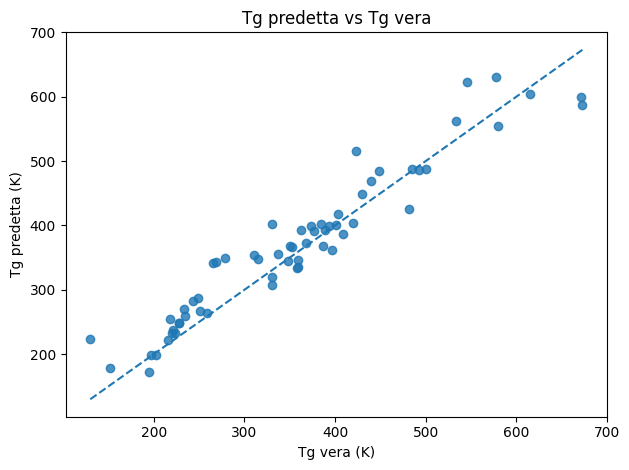

In [22]:

plt.figure()
plt.scatter(y_test, pred_perm, alpha=0.8)


# diagonale ideale
min_val = min(y_test.min(), pred_perm.min())
max_val = max(y_test.max(), pred_perm.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Tg vera (K)")
plt.ylabel("Tg predetta (K)")
plt.title("Tg predetta vs Tg vera")

plt.tight_layout()
plt.show()

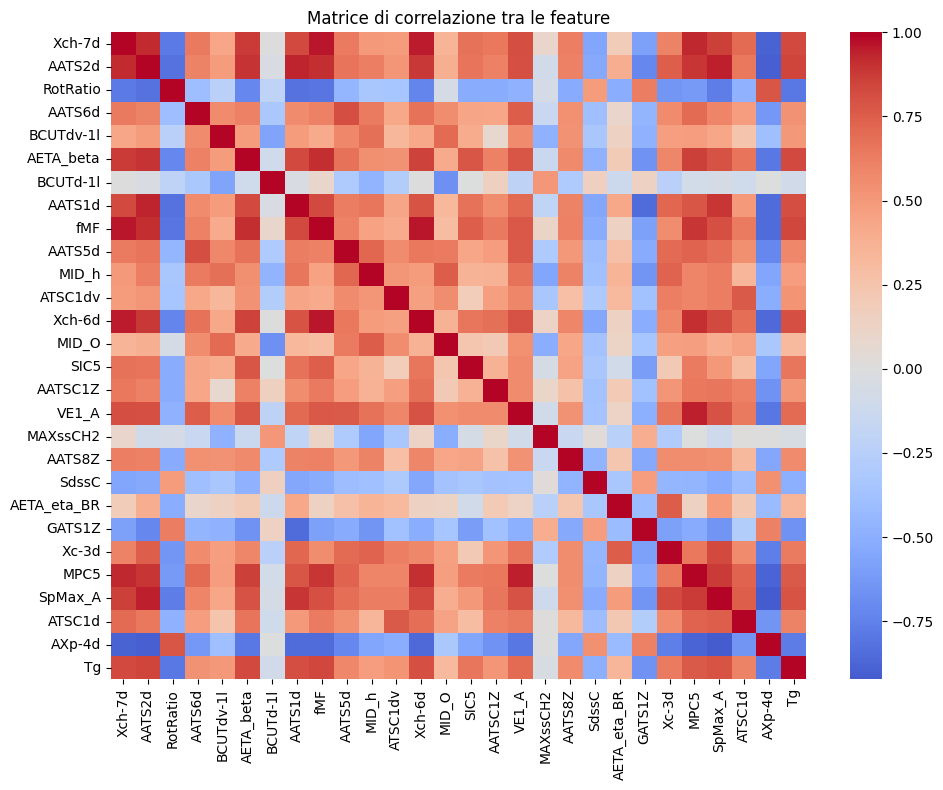

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

test=pd.concat([X_perm_selected.reset_index().drop(columns=["_id"]), pd.DataFrame(y)], axis=1)
corr = test.corr(method="spearman")
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matrice di correlazione tra le feature")
plt.tight_layout()
plt.show()

## Cross validation finale

In [24]:
from sklearn.model_selection import GridSearchCV, KFold

param_grid = {
    "n_estimators": [200, 400, 800],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0]
}

gb = GradientBoostingRegressor(random_state=random_state)

# Cross-validation 5 fold
cv = KFold(n_splits=5, shuffle=True, random_state=random_state)

# Grid search
grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Risultati tuning
print("Best parameters found:")
print(grid_search.best_params_)

print("\nBest CV MAE:")
print(-grid_search.best_score_)

# 8. Valutazione finale su test set
best_model = grid_search.best_estimator_
pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("\nPerformance on Test Set:")
print(f"MAE: {mae}")
print(f"R² : {r2}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters found:
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 400, 'subsample': 0.8}

Best CV MAE:
26.998650686762677

Performance on Test Set:
MAE: 29.828126599049348
R² : 0.9003186442962035


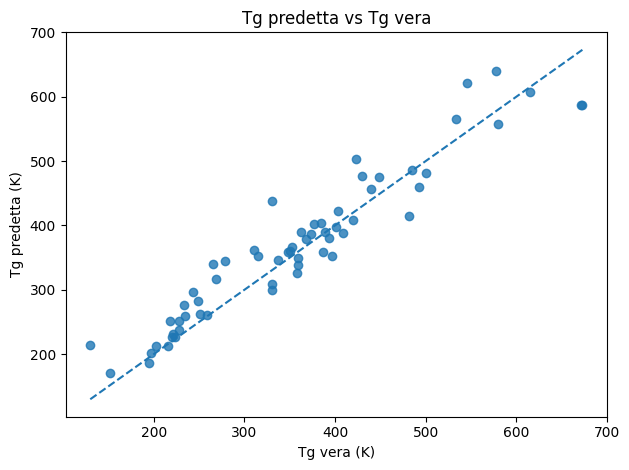

In [25]:

plt.figure()
plt.scatter(y_test, pred, alpha=0.8)


# diagonale ideale
min_val = min(y_test.min(), pred.min())
max_val = max(y_test.max(), pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Tg vera (K)")
plt.ylabel("Tg predetta (K)")
plt.title("Tg predetta vs Tg vera")

plt.tight_layout()
plt.show()

### UMAP

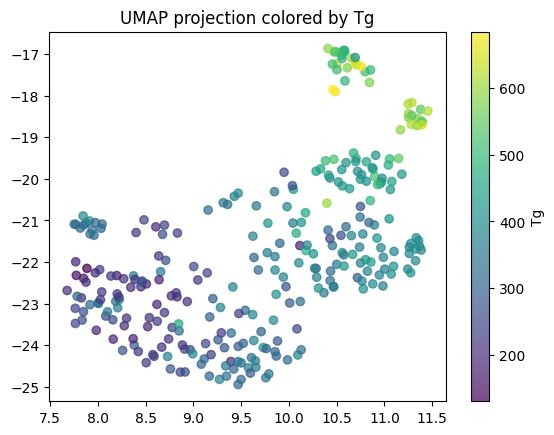

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

import umap

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = reducer.fit_transform(X_scaled)

plt.scatter(X_umap[:,0], X_umap[:,1], c=y, alpha=0.7)
plt.colorbar(label="Tg")
plt.title("UMAP projection colored by Tg")
plt.show()

In [27]:
from sklearn.cluster import KMeans

labels = KMeans(n_clusters=2, random_state=42).fit_predict(X_umap)

In [28]:
df_umap = pd.DataFrame(X_umap, columns=["UMAP1", "UMAP2"])
df_umap["cluster"] = labels
df_umap["Tg"] = y.values

df_umap.groupby("cluster")["Tg"].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,214.0,308.981308,75.346708,130.0,239.25,319.0,373.00,482.0
1,90.0,483.222222,98.073325,255.0,412.00,485.5,561.75,685.0


In [29]:
X_clustered = X.copy()
X_clustered["cluster"] = labels

cluster_means = X_clustered.groupby("cluster").mean()
(cluster_means.loc[1] - cluster_means.loc[0]).abs().sort_values(ascending=False).head(10)

Ipc      1.833655e+12
WPath    4.377551e+03
ATS4Z    2.140964e+03
ATS5Z    2.057741e+03
ATS3Z    2.003053e+03
ATS6Z    1.924355e+03
VR1_A    1.772396e+03
ATS7Z    1.758461e+03
ATS2Z    1.669814e+03
ATS8Z    1.564582e+03
dtype: float64

In [ ]:
from sklearn.preprocessing import StandardScaler

X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X),
    columns=X.columns,
    index=X.index
)
X_clustered = X_scaled.copy()
X_clustered["cluster"] = labels

cluster_means = X_clustered.groupby("cluster").mean()
(cluster_means.loc[1] - cluster_means.loc[0]).abs().sort_values(ascending=False).head(10)

### Univariate regression - Analisi dei descrittori (solo per esplorazione)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

scores = []

for col in X.columns:
    X_col = X[[col]] 
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_col, y, test_size=0.2, random_state=random_state
    )
    
    model = RandomForestRegressor(n_estimators=200, random_state=random_state)
    model.fit(X_train, y_train)
    
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    
    scores.append({
        "feature": col,
        "MAE": mae,
        "R2": r2
    })

import pandas as pd
results = pd.DataFrame(scores)
results_sorted = results.sort_values("MAE")
results_sorted.head(20)

In [ ]:
results.sort_values("R2", ascending=False).head(20)

In [ ]:
import seaborn as sns
plt.figure(figsize=(8,12))
sns.barplot(data=results_sorted.head(25), x="MAE", y="feature")
plt.title("Top 25 descrittori per MAE (più basso = migliore)")
plt.show()
